Load the dataset with PySpark

In [49]:
from pyspark.sql import SparkSession
from pathlib import Path
from pyspark.sql import functions as F
import country_converter as coco
from itertools import chain

CLEANED_DATA_DIR = Path("../data/cleaned")
PROCESSED_DATA_DIR = Path("../data")

spark = SparkSession.builder.appName("profiling").config("spark.sql.ansi.enabled", "false").config("spark.driver.memory", "16g").getOrCreate()
df = spark.read.parquet(f"{PROCESSED_DATA_DIR}/4_eea_co2_emissions_from_passenger_cars-001.parquet")

last_present = df.count()
print(f"{last_present} rows present")

79400771 rows present


Remap column names to more easily understandable ones

In [50]:
column_mapping = {
    "Country": "geo",
    "VFN": "vehicle_family_id_number",
    "Mh": "manufacturer_name_eu_standard_denomination",
    "T": "type",
    "Va": "variant",
    "Ve": "version",
    "Mk": "make",
    "Cn": "commercial_name",
    "m (kg)": "mass_in_running_order (kg)",
    "Ewltp (g/km)": "co2_emissions_WLTP (g/km)",
    "Ft": "Motor energy",
    "Fm": "fuel_mode",
    "ec (cm3)": "engine_capacity (cm3)",
    "ep (KW)": "engine_power (KW)",
    "z (Wh/km)": "electric_energy_consumption (Wh/km)",
    "r": "registrations",
    "year": "TIME_PERIOD"
}

for old_col, new_col in column_mapping.items():
    df = df.withColumnRenamed(old_col, new_col)

Drop non EU countries

In [51]:
eu27_2020 = ['BE', 'BG', 'CZ', 'DK', 'DE', 'EE', 'IE', 'EL', 'ES', 'FR', 'HR', 'IT', 'CY', 'LV', 'LT', 'LU', 'HU', 'MT', 'NL', 'AT', 'PL', 'PT', 'RO', 'SI', 'SK', 'FI', 'SE']
country_dict = {code: coco.convert(names=code, to='name_short', not_found=None) for code in eu27_2020}

df = df.filter(df["geo"].isin(eu27_2020))

last_present = df.count()

Drop  N/A values

In [52]:
num_cols = [
   "mass_in_running_order (kg)", "co2_emissions_WLTP (g/km)", 
    "engine_capacity (cm3)", "engine_power (KW)", "electric_energy_consumption (Wh/km)"
]
str_cols = ["geo", "commercial_name", "Motor energy"]
all_cols = str_cols + num_cols

df = df.na.drop(subset=str_cols)
df = df.filter(df["TIME_PERIOD"] != 0)

print(f"Row count changed by: {last_present - df.count()}")
last_present = df.count()
print(f"{last_present} rows present")

Row count changed by: 181821
71101959 rows present


Drop columns we don't need

In [53]:
not_needed = ["vehicle_family_id_number", "version", "make", "fuel_mode", "type", "variant"]
df = df.drop(*not_needed)

Clean the Motor Energy column to remove all various duplicates and unnecessary values, then group the various motor energy types in the ones we intend to analyse

In [54]:
df = df.withColumn("Motor energy", 
    F.regexp_replace(F.trim(F.lower(F.col("Motor energy"))), "-", "/")
)
df.select("Motor energy").distinct().orderBy("Motor energy").rdd.map(lambda row: row[0]).collect()

['',
 'biodiesel',
 'cng',
 'diesel',
 'diesel/electric',
 'e85',
 'electric',
 'gnl',
 'hybrid/petrol/e',
 'hydrogen',
 'lpg',
 'ng',
 'ng/biomethane',
 'other',
 'petrol',
 'petrol phev',
 'petrol/electric',
 'petrol/gas',
 'unknown']

In [55]:
unnecessary = ["unknown", "other"]
df = df.filter(~df["Motor energy"].isin(unnecessary))

df = df.withColumn(
    "Motor energy",
    F.when(F.col("Motor energy") == "electric", "Electricity")
     .when(F.col("Motor energy").isin("petrol/electric", "hybrid/petrol/e", "petrol phev"), "Petrol hybrid")
     .when(F.col("Motor energy") == "diesel/electric", "Diesel hybrid")
     .when(F.col("Motor energy") == "petrol", "Petrol (excluding hybrids)")
     .when(F.col("Motor energy") == "diesel", "Diesel (excluding hybrids)")
     .otherwise("Alternative/Other") 
)

print(f"Row count changed by: {last_present - df.count()}")
last_present = df.count()
print(f"{last_present} rows present")

Row count changed by: 2213
71099746 rows present


Clean the manufacturer_name_eu_standard_denomination column, removing unnecessary values and reducing duplicates

In [56]:
df = df.filter(~F.col("manufacturer_name_eu_standard_denomination").isin("DUPLICATE", "OUT OF SCOPE", "UNKNOWN", "duplicate", "unknown"))

name_map = {
    "AUDI HUNGARIA": "AUDI AG",
    "AUDI SPORT": "AUDI AG",
    "BEE": "BEE BEE",
    "BLUECAR ITALY": "BLUECAR",
    "BMW GMBH": "BMW AG",
    "DONGFENG LIUZHOU": "DONGFENG",
    "DONGFENG MOTOR": "DONGFENG",
    "DONKEVOORT": "DONKERVOORT",
    "DR MOTOR": "DR AUTOMOBILES",
    "Duplicate": "DUPLICATE",
    "FORD INDIA": "FORD MOTOR COMPANY",
    "FORD MOTOR AUSTRALIA": "FORD MOTOR COMPANY",
    "FORD WERKE GMBH": "FORD MOTOR COMPANY",
    "Ford Motor Company": "FORD MOTOR COMPANY",
    "GENERAL MOTORS COMPANY": "GENERAL MOTORS",
    "GENERAL MOTORS HOLDINGS": "GENERAL MOTORS",
    "GM ITALIA": "GENERAL MOTORS",
    "GM KOREA": "GENERAL MOTORS",
    "GM KOREA": "GENERAL MOTORS",
    "HONDA CHINA": "HONDA",
    "HONDA MOTOR CO": "HONDA",
    "HONDA THAILAND": "HONDA",
    "HONDA TURKIYE": "HONDA",
    "HONDA UK": "HONDA",
    "HYUNDAI ASSAN": "HYUNDAI",
    "HYUNDAI ASSAN": "HYUNDAI",
    "HYUNDAI CZECH": "HYUNDAI",
    "HYUNDAI CZECH": "HYUNDAI",
    "HYUNDAI EUROPE": "HYUNDAI",
    "HYUNDAI INDIA": "HYUNDAI",
    "JIANGXI JIANGLING": "JIANGLING MOTOR",
    "KIA SLOVAKIA": "KIA",
    "KIA SLOVAKIA": "KIA",
    "LADA FRANCE": "LADA",
    "LANZHOU ZHIDOU": "LANZHOU",
    "MAGYAR SUZUKI": "SUZUKI MOTOR CORPORATION",
    "MARUTI SUZUKI": "SUZUKI MOTOR CORPORATION",
    "MAZDA EUROPE": "MAZDA",
    "MERCEDES AMG": "MERCEDES-BENZ AG",
    "MERCEDES-AMG": "MERCEDES-BENZ AG",
    "NISSAN AUTOMOTIVE EUROPE": "NISSAN",
    "OPEL AUTOMOBILE": "OPEL",
    "QUATTRO": "AUDI AG",
    "RADICAL MOTOSPORT": "RADICAL MOTORSPORT",
    "ROLLS-ROYCE": "ROLLS ROYCE",
    "SAIC MAXUS": "SAIC MOTOR CORPORATION",
    "SAIC MOTOR": "SAIC MOTOR CORPORATION",
    "STELLANTIS EUROPE": "STELLANTIS AUTO",
    "SUZUKI THAILAND": "SUZUKI MOTOR CORPORATION",
    "TOYOTA MOTOR CORPORATION": "TOYOTA",
    "WUHAN LOTUS": "LOTUS"
}

df = df.replace(name_map, subset=["manufacturer_name_eu_standard_denomination"])
print(f"Row count changed by: {last_present - df.count()}")
last_present = df.count()
print(f"{last_present} rows present")

Row count changed by: 59394
71040352 rows present


Aggregate registrations by merging rows that are now duplicated, construct a new standard geopoliticaly entity column like with the other datasets, then finally reorder columns and write the results to disk

In [57]:
grouping_columns = [col for col in df.columns if col != "registrations"]
df = df.groupBy(*grouping_columns) \
               .agg(F.sum("registrations").alias("registrations"))

mapping_expr = F.create_map([F.lit(x) for x in chain(*country_dict.items())])
df = df.withColumn("Geopolitical entity (reporting)", mapping_expr[F.col("geo")])

df = df.withColumn("registrations", F.col("registrations").cast("integer"))

df = df.select(
    "geo",
    "Geopolitical entity (reporting)",
    "TIME_PERIOD",
    "registrations",
    "manufacturer_name_eu_standard_denomination",
    "commercial_name",
    "Motor energy",
    "mass_in_running_order (kg)",
    "co2_emissions_WLTP (g/km)",
    "engine_capacity (cm3)",
    "engine_power (KW)",
    "electric_energy_consumption (Wh/km)"
)

print(f"Row count changed by: {last_present - df.count()}")
last_present = df.count()
print(f"{last_present} rows present")

Row count changed by: 68848074
2192278 rows present


# FROM HERE

> Probably zeros / null values need to be resolved before aggregation so we also have more columns to find the correct values to impute. 

> If not we can try to search for the same car 'commercial_name' and 'manufacturer_name_eu_standard_denomination' and other categories that enable to distinguish univoquely the car we can try to impute the missing values!

Restrict temporal coverage of both datasets to the years 2014-2023.

In [58]:
df = df.filter((F.col("TIME_PERIOD") >= 2014) & (F.col("TIME_PERIOD") <= 2023))

Convert numeric columns to the correct data type.

> TODO: Check if 'int' is fine or we need to use 'double'!

In [59]:
df = df.withColumn("mass_in_running_order (kg)", F.col("mass_in_running_order (kg)").cast("int")) \
       .withColumn("co2_emissions_WLTP (g/km)", F.col("co2_emissions_WLTP (g/km)").cast("int")) \
       .withColumn("engine_capacity (cm3)", F.col("engine_capacity (cm3)").cast("int")) \
       .withColumn("engine_power (KW)", F.col("engine_power (KW)").cast("int")) \
       .withColumn("electric_energy_consumption (Wh/km)", F.col("electric_energy_consumption (Wh/km)").cast("int"))

In [60]:
df.show(10, truncate=False)

+---+-------------------------------+-----------+-------------+------------------------------------------+------------------+-------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
|geo|Geopolitical entity (reporting)|TIME_PERIOD|registrations|manufacturer_name_eu_standard_denomination|commercial_name   |Motor energy |mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|
+---+-------------------------------+-----------+-------------+------------------------------------------+------------------+-------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
|DE |Germany                        |2023       |336          |SEAT                                      |FORMENTOR E-HYBRID|Petrol hybrid|1680                      |30                       |1

Check zeros / null values in the 'co2_emissions_WLTP (g/km)' column

> Most zeros are associated with 'Motor energy' = 'Electricity', some with 'Motor energy' = 'Alternative/Other'. If not needed for the dashboard we can decide wether to drop the 'Alternative/Other' category in the dataset.

> TODO: null values need to be imputed there are lots!

In [61]:
df.filter(F.col("co2_emissions_WLTP (g/km)") == 0).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

+-----------------+-----+
|     Motor energy|count|
+-----------------+-----+
|      Electricity|81874|
|Alternative/Other|  130|
+-----------------+-----+



In [62]:
df.filter(F.col("co2_emissions_WLTP (g/km)").isNull()).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

+--------------------+------+
|        Motor energy| count|
+--------------------+------+
|Diesel (excluding...|291941|
|Petrol (excluding...|254732|
|   Alternative/Other|  7678|
|       Petrol hybrid|  6397|
|         Electricity|  4016|
|       Diesel hybrid|   895|
+--------------------+------+



In [63]:
df.filter(F.col("co2_emissions_WLTP (g/km)").isNull()).groupBy("manufacturer_name_eu_standard_denomination").count().orderBy(F.col("count").desc()).show(truncate=False)

+------------------------------------------+-----+
|manufacturer_name_eu_standard_denomination|count|
+------------------------------------------+-----+
|VOLKSWAGEN                                |53901|
|BMW AG                                    |51277|
|AUDI AG                                   |46054|
|DAIMLER AG                                |45531|
|AA-IVA                                    |29676|
|SKODA                                     |27946|
|FORD MOTOR COMPANY                        |27885|
|OPEL                                      |27835|
|FIAT GROUP                                |19843|
|RENAULT                                   |18760|
|AUTOMOBILES PEUGEOT                       |18262|
|AUTOMOBILES CITROEN                       |16912|
|NISSAN                                    |16507|
|TOYOTA                                    |15889|
|JAGUAR LAND ROVER LIMITED                 |15876|
|VOLVO                                     |15763|
|KIA                           

Check zeros / null values in the 'engine_capacity (cm3)' column

> No zeros found!

> TODO: null values, apart from the 'Motor energy' = 'Electricity' category,are also in some rows with 'Motor energy' in 'Petrol' and 'Diesel' categories!

In [64]:
df.filter(F.col("engine_capacity (cm3)") == 0).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

+------------+-----+
|Motor energy|count|
+------------+-----+
+------------+-----+



In [65]:
df.filter(F.col("engine_capacity (cm3)").isNull()).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

+--------------------+-----+
|        Motor energy|count|
+--------------------+-----+
|         Electricity|85878|
|Petrol (excluding...| 1048|
|Diesel (excluding...|  749|
|   Alternative/Other|  188|
|       Petrol hybrid|   83|
|       Diesel hybrid|    4|
+--------------------+-----+



In [66]:
df.filter(F.col("engine_capacity (cm3)").isNull()).filter(F.col("Motor energy") != "Electricity").show()

+---+-------------------------------+-----------+-------------+------------------------------------------+--------------------+--------------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
|geo|Geopolitical entity (reporting)|TIME_PERIOD|registrations|manufacturer_name_eu_standard_denomination|     commercial_name|        Motor energy|mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|
+---+-------------------------------+-----------+-------------+------------------------------------------+--------------------+--------------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
| PL|                         Poland|       2023|           35|                                   HYUNDAI|                NEXO|   Alternative/Other|                  

Check zeros / null values in the 'engine_power (KW)' column

> Few zeros associated with 'Motor energy' = 'Petrol (excluding hybrid)' and 'Motor energy' = 'Diesel (excluding hybrid)'. Are all from 'BMW AG'!

>

In [67]:
df.filter(F.col("engine_power (KW)") == 0).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

+--------------------+-----+
|        Motor energy|count|
+--------------------+-----+
|Diesel (excluding...|   17|
|Petrol (excluding...|   12|
+--------------------+-----+



In [68]:
df.filter(F.col("engine_power (KW)") == 0).show(30, truncate=False)

+---+-------------------------------+-----------+-------------+------------------------------------------+---------------+--------------------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
|geo|Geopolitical entity (reporting)|TIME_PERIOD|registrations|manufacturer_name_eu_standard_denomination|commercial_name|Motor energy              |mass_in_running_order (kg)|co2_emissions_WLTP (g/km)|engine_capacity (cm3)|engine_power (KW)|electric_energy_consumption (Wh/km)|
+---+-------------------------------+-----------+-------------+------------------------------------------+---------------+--------------------------+--------------------------+-------------------------+---------------------+-----------------+-----------------------------------+
|CY |Cyprus                         |2014       |4            |BMW AG                                    |X5 SDRIVE25D   |Diesel (excluding hybrids)|2070          

In [69]:
df.filter(F.col("engine_power (KW)").isNull()).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

+--------------------+-----+
|        Motor energy|count|
+--------------------+-----+
|Diesel (excluding...|26978|
|Petrol (excluding...|23143|
|         Electricity| 9023|
|       Petrol hybrid| 1103|
|   Alternative/Other|  507|
|       Diesel hybrid|  201|
+--------------------+-----+



Check zeros / null values in the 'electric_energy_consumption (Wh/km)' column

> TODO: categories that should not have values have them, and categories that should have values don't have them. Need to check if we can do something about this!

In [70]:
df.filter(F.col("electric_energy_consumption (Wh/km)") == 0).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

+------------+-----+
|Motor energy|count|
+------------+-----+
+------------+-----+



In [71]:
df.filter(F.col("electric_energy_consumption (Wh/km)") != 0).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

+--------------------+------+
|        Motor energy| count|
+--------------------+------+
|       Petrol hybrid|105021|
|         Electricity| 80388|
|       Diesel hybrid| 11980|
|Petrol (excluding...|   656|
|Diesel (excluding...|   187|
|   Alternative/Other|     8|
+--------------------+------+



In [72]:
df.filter(F.col("electric_energy_consumption (Wh/km)").isNull()).groupBy("Motor energy").count().orderBy(F.col("count").desc()).show()

+--------------------+------+
|        Motor energy| count|
+--------------------+------+
|Petrol (excluding...|952302|
|Diesel (excluding...|902275|
|   Alternative/Other| 18805|
|       Petrol hybrid| 13662|
|         Electricity|  5502|
|       Diesel hybrid|  2535|
+--------------------+------+



Save the cleaned dataset to disk in parquet format.

In [73]:
df.write.mode("overwrite") \
    .option("compression", "gzip") \
    .parquet(f"{CLEANED_DATA_DIR}/4c_eea_co2_emissions_from_passenger_cars-001.parquet")

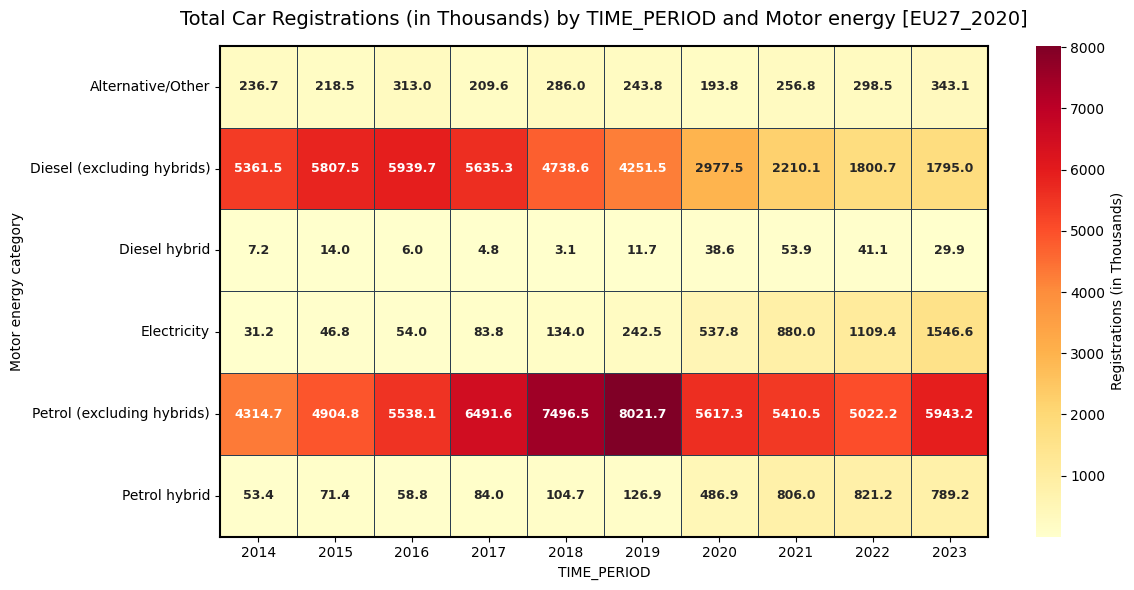

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pivoted_df = (
    df.groupBy("Motor energy")
      .pivot("TIME_PERIOD")
      .agg(F.round(F.sum("registrations") / 1000, 1))
      .fillna(0)
      .orderBy("Motor energy")
)

raw_rows = pivoted_df.collect()
columns = pivoted_df.columns
years = sorted([c for c in columns if c != "Motor energy"])

matrix_dict = {
    r["Motor energy"]: [r[y] for y in years]
    for r in raw_rows
}

heatmap_data = pd.DataFrame.from_dict(matrix_dict, orient="index", columns=years)

plt.figure(figsize=(12, 6))
ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="",
    annot_kws={"weight": "bold", "size": 9},
    cmap="YlOrRd",
    linewidths=0.5,
    linecolor="#2c3e50",
    cbar_kws={'label': 'Registrations (in Thousands)'}
)

# Heatmap border
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.5)

plt.title("Total Car Registrations (in Thousands) by TIME_PERIOD and Motor energy [EU27_2020]", fontsize=14, pad=15)
plt.xlabel("TIME_PERIOD")
plt.ylabel("Motor energy category")
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("img/powertrain_year_heatmap.png", dpi=300)
plt.show()